# Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("HR_comma_sep.csv")

#Data cleaning

data = data.dropna()


# Undestanding factors that contribute most to employee turnover.

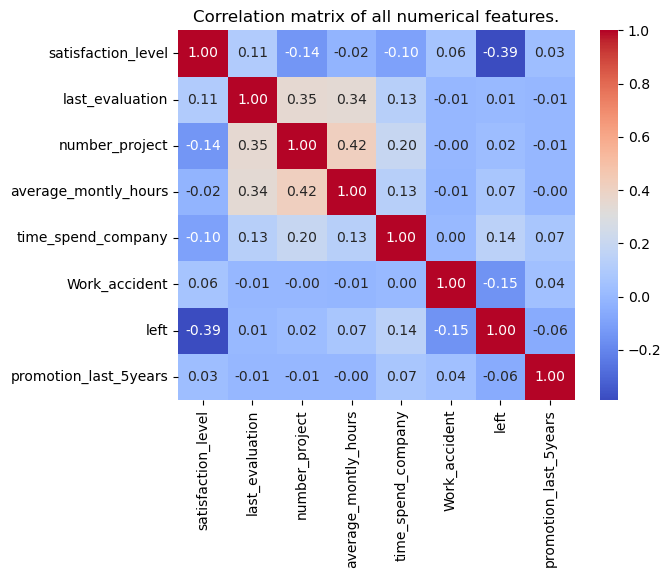

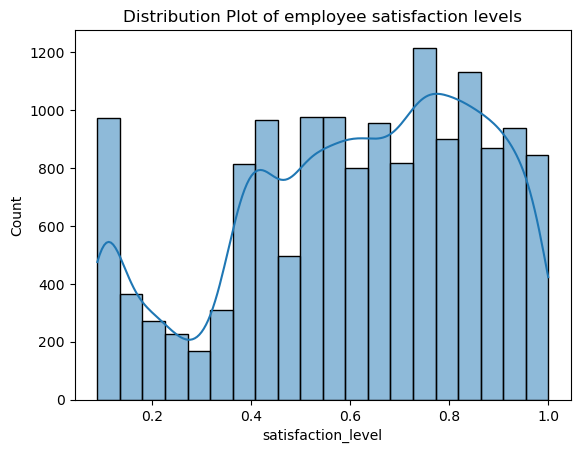

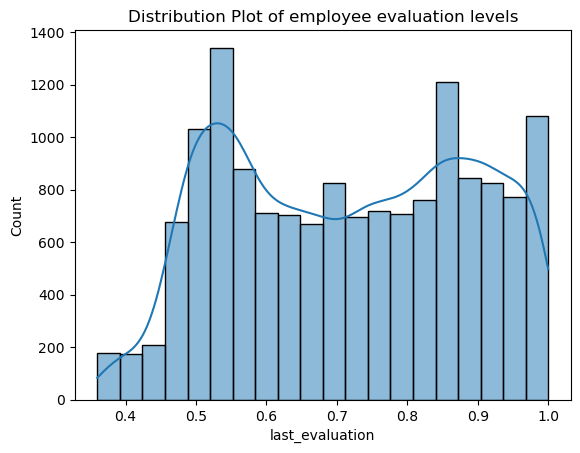

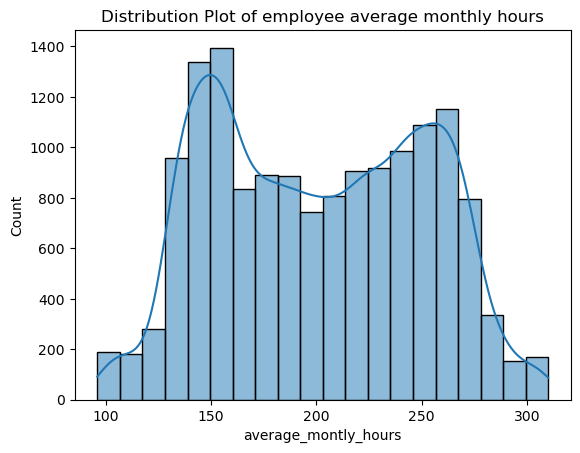

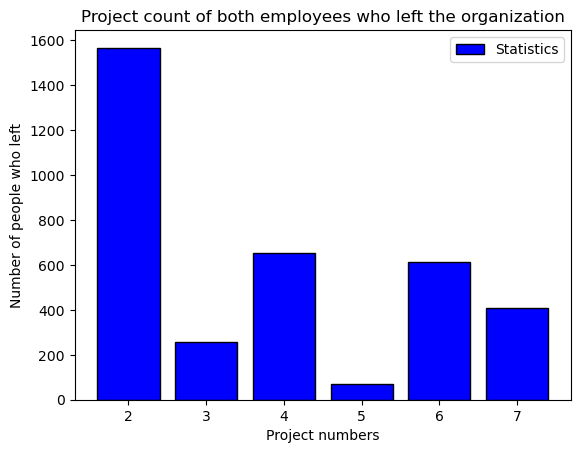

In [2]:
correlation_matrix = data.select_dtypes(include='number').corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix of all numerical features.")
plt.show()

sns.histplot(data['satisfaction_level'], bins=20, kde=True)
plt.title("Distribution Plot of employee satisfaction levels")
plt.show()

sns.histplot(data['last_evaluation'], bins=20, kde=True)
plt.title("Distribution Plot of employee evaluation levels")
plt.show()

sns.histplot(data['average_montly_hours'], bins=20, kde=True)
plt.title("Distribution Plot of employee average monthly hours")
plt.show()

project_numbers = data['number_project'].unique()

left = data.groupby('number_project')['left'].sum().unique()

plt.bar(project_numbers, left, color='blue', edgecolor='black', label='Statistics')

plt.xlabel('Project numbers')
plt.ylabel('Number of people who left')
plt.title('Project count of both employees who left the organization')

plt.legend()

plt.show()

# Perform clustering of employees who left based on their satisfaction and evaluation

In [ ]:
#Perform clustering of employees who left based on their satisfaction and evaluation

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler


columns = data[['satisfaction_level', 'last_evaluation', 'left']].values

scaler = MinMaxScaler(feature_range=(0.2,0.8))

columns = scaler.fit_transform(columns)

model = KMeans(n_clusters = 3, n_init=10, init= 'k-means++', random_state=42)
y_kmeans = model.fit_predict(columns)

plt.scatter(columns[y_kmeans == 0, 0], columns[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(columns[y_kmeans == 1, 0], columns[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(columns[y_kmeans == 2, 0], columns[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=300, c='yellow', label='Centroids')
plt.title('Clusters of employees who left the company')
plt.xlabel('Satisfaction levels')
plt.ylabel('Last evaluation')
plt.legend()
plt.show()

# Handle the left Class Imbalance using the SMOTE technique

In [ ]:
#Handle the left Class Imbalance using the SMOTE technique

data_categorical = data.select_dtypes(exclude='number')
data_numerical = data.select_dtypes(include='number')

data_categorical_encoded = pd.get_dummies(data_categorical)

new_data = pd.concat([data_categorical_encoded, data_numerical], axis=1).drop('left', axis=1)

y = data['left'].astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(new_data, y, test_size=0.2, random_state=123, stratify=y)

from imblearn.over_sampling import SMOTE


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

plt.figure(figsize=(10,5))
plt.scatter(X_train_sc[:, 0], X_train_sc[:, 1], c = y_train, alpha=0.5, cmap='viridis', marker='o')
plt.title('Imbalanced Data')

plt.show()

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

plt.figure(figsize=(10,5))
plt.scatter(X_train_smote[:, 0], X_train_smote[:, 1], c=y_train_smote, alpha=0.5, cmap='viridis', marker='o')
plt.title('Balanced Data')

plt.show()

# Perform 5-fold cross-validation model training and evaluate performance

In [ ]:
#Perform 5-fold cross-validation model training and evaluate performance

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay


pipeline = Pipeline([
  ('log_reg', LogisticRegression(max_iter=10000, random_state=42))
])

pipeline.fit(X_train_smote, y_train_smote)

y_pred_test_log_reg = pipeline.predict(X_test_sc)

print("Logistic Regression classification report\n")

print(classification_report(y_test, y_pred_test_log_reg), "\n")

cv_scores = cross_val_score(pipeline, X_train_smote, y_train_smote, cv=5)

print("Cross Validation Scores\n")

print(cv_scores, "\n")

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_test_rf = rf_model.predict(X_test_sc)

print("Random Forest classification report\n")

print(classification_report(y_test, y_pred_test_rf), "\n")

cv_scores = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=5)

print("Cross Validation Scores\n")

print(cv_scores, "\n")

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=7)

gb_model.fit(X_train_smote, y_train_smote)

y_pred_test_gb = gb_model.predict(X_test_sc)

print("Gradient Boosting classification report\n")

print(classification_report(y_test, y_pred_test_gb), "\n")

cv_scores = cross_val_score(gb_model, X_train_smote, y_train_smote, cv=5)

print("Cross Validation Scores\n")

print(cv_scores, "\n")


# Identify the best model and justify the evaluation metrics used.

In [ ]:
#Identify the best model and justify the evaluation metrics used.

import numpy as np

#Logistic Regression model

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_log_reg)

roc_auc = auc(fpr, tpr)

youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0,1], [0,1], color= 'grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred_test_log_reg)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix)

cm_display.plot()
plt.show()



#Random Forest Classifier Model

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_rf)

roc_auc = auc(fpr, tpr)

youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0,1], [0,1], color= 'grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred_test_rf)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix)

cm_display.plot()
plt.show()

#Gradient Boosting Classifier Model

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_gb)

roc_auc = auc(fpr, tpr)

youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0,1], [0,1], color= 'grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred_test_gb)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix)

cm_display.plot()
plt.show()